# Métodos Hierárquicos Divisivos: Bisecting K-Means e DIANA

## Introdução

Os **métodos divisivos** iniciam com todos os dados em um único cluster e realizam divisões sucessivas até alcançar clusters menores. Diferem dos métodos aglomerativos que fazem o caminho oposto. São menos explorados porque a decisão inicial de como dividir é mais crítica e custosa computacionalmente.

O **Bisecting K-Means** é uma variação do K-Means que aplica divisão hierárquica usando o critério de **SSE (Sum of Squared Errors)** para escolher qual cluster dividir.

O **DIANA** (Divisive Analysis) usa o conceito de **diâmetro do cluster** (maior distância entre pares de elementos) e o elemento mais divergente para orientar as divisões.

In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

# Semente para reprodutibilidade
SEED = 42
np.random.seed(SEED)

## Base de Dados Sintética

Geramos uma base sintética com 4 grupos bem definidos usando `make_blobs` para demonstrar o funcionamento do Bisecting K-Means.

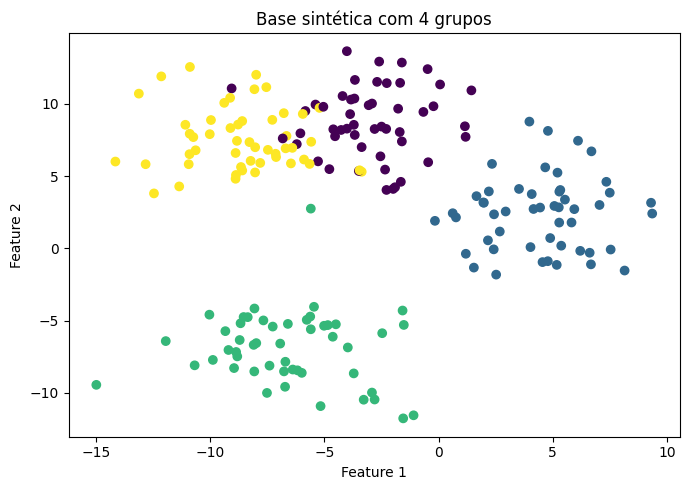

Shape dos dados: (200, 2)


In [14]:
# base sintética com make_blobs

# gerando 4 grupos bem definidos
X, y_true = make_blobs(
    n_samples=200,
    centers=4,
    cluster_std=2.5, 
    random_state=SEED
)

# visualização
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_true)
plt.title("Base sintética com 4 grupos")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

print(f"Shape dos dados: {X.shape}")

## Bisecting K-Means: Implementação

**Algoritmo:**
1. Inicia com um cluster contendo todos os pontos
2. Enquanto o número de clusters < k:
   - Seleciona o cluster com **maior SSE** (critério de escolha)
   - Divide-o em 2 sub-clusters usando K-Means com k=2
   - Substitui o cluster original pelos dois novos

**SSE (Sum of Squared Errors):** Soma das distâncias quadráticas de cada ponto ao centroide do seu cluster. Um SSE alto indica cluster disperso, merecedor de divisão.

In [15]:
# Bisecting K-Means


def calcular_sse(pontos):
    """
    SSE = soma das distâncias quadráticas de cada ponto ao centroide.
    Critério usado para escolher qual cluster dividir (maior SSE).
    """
    centroide = pontos.mean(axis=0)
    return ((pontos - centroide) ** 2).sum()


# bisecting K-Means manual
def bisecting_kmeans(X, k):
    """
    Implementação manual do Bisecting K-Means.
    Retorna a lista de clusters (arrays de índices) e o histórico de SSE.
    """
    # primeiro temos um único cluster com todos os pontos
    clusters = [np.arange(len(X))]
    historico = []

    while len(clusters) < k:

        # escolhemo o cluster com maior SSE para dividir
        sse_por_cluster = [calcular_sse(X[c]) for c in clusters]
        idx_escolhido = np.argmax(sse_por_cluster)

        pontos_escolhidos = X[clusters[idx_escolhido]]
        indices_escolhidos = clusters[idx_escolhido]

        print(f"\nCluster escolhido: {idx_escolhido}")
        print(f"SSE do cluster escolhido: {sse_por_cluster[idx_escolhido]:.2f}")
        
        # dividimos em 2 usando K-Means com k=2
        km = KMeans(n_clusters=2, random_state=SEED, n_init=10)
        rotulos = km.fit_predict(pontos_escolhidos)

        # 2 novos clusters resultantes da divisão
        cluster_a = indices_escolhidos[rotulos == 0]
        cluster_b = indices_escolhidos[rotulos == 1]

        # substituimos o cluster dividido pelos dois novos
        clusters.pop(idx_escolhido)
        clusters.extend([cluster_a, cluster_b])

        # registramos o SSE total após a divisão
        sse_total = sum(calcular_sse(X[c]) for c in clusters)
        historico.append({
            "num_clusters": len(clusters),
            "sse_total": round(sse_total, 2)
        })

        print(f"Divisão {len(clusters)-1}: {len(clusters)} clusters | SSE total = {sse_total:.2f}")

    return clusters, historico


# executamos com k=4 (sabemos que a base tem 4 grupos)
clusters_bkm, historico = bisecting_kmeans(X, k=4)


Cluster escolhido: 0
SSE do cluster escolhido: 14853.08
Divisão 1: 2 clusters | SSE total = 7657.71

Cluster escolhido: 0
SSE do cluster escolhido: 7050.92
Divisão 2: 3 clusters | SSE total = 3011.63

Cluster escolhido: 2
SSE do cluster escolhido: 1719.36
Divisão 3: 4 clusters | SSE total = 2164.42


## Resultados e Comparação

Comparamos o Bisecting K-Means com o K-Means tradicional. Ambos visam minimizar SSE, mas por caminhos diferentes:
- **Bisecting K-Means:** caminho top-down (divisivo)
- **K-Means tradicional:** centróides aleatórios, refinamento iterativo

Analisamos a evolução do SSE total conforme os clusters são divididos.

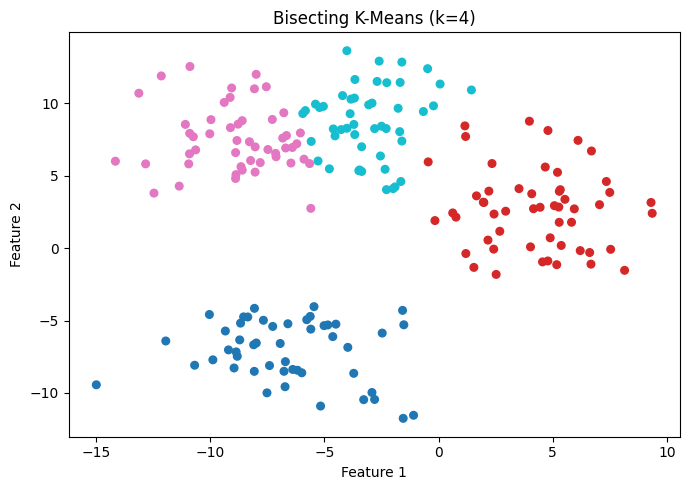

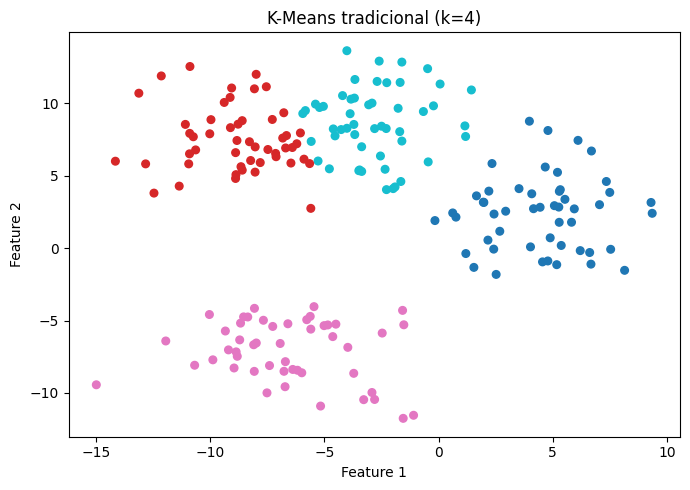

 num_clusters  sse_total
            2    7657.71
            3    3011.63
            4    2164.42


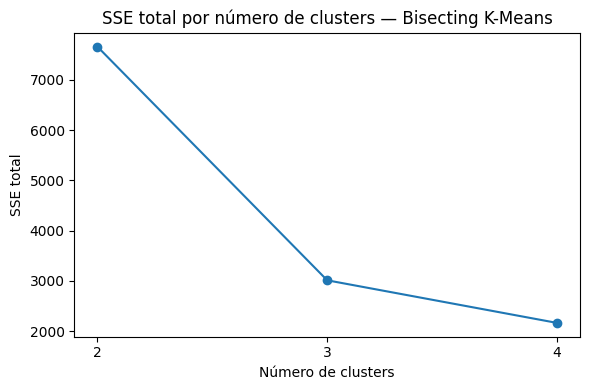

SSE final — Bisecting K-Means : 2164.42
SSE final — K-Means tradicional: 2095.23


In [16]:
# Visualização e Comparação

# Resultado do Bisecting K-Means

# Montar array de rótulos para plotar
rotulos_bkm = np.empty(len(X), dtype=int)
for i, cluster in enumerate(clusters_bkm):
    rotulos_bkm[cluster] = i

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=rotulos_bkm, cmap='tab10', s=30)
plt.title("Bisecting K-Means (k=4)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()


# Resultado do K-Means tradicional

km_trad = KMeans(n_clusters=4, random_state=SEED, n_init=10)
rotulos_km = km_trad.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=rotulos_km, cmap='tab10', s=30)
plt.title("K-Means tradicional (k=4)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()


# Evolução do SSE ao longo das divisões

df_historico = pd.DataFrame(historico)
print(df_historico.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.plot(df_historico["num_clusters"], df_historico["sse_total"], marker='o')
plt.title("SSE total por número de clusters — Bisecting K-Means")
plt.xlabel("Número de clusters")
plt.ylabel("SSE total")
plt.xticks(df_historico["num_clusters"])
plt.tight_layout()
plt.show()


# Comparação direta de SSE final

sse_bkm = sum(calcular_sse(X[c]) for c in clusters_bkm)
sse_km  = km_trad.inertia_

print(f"SSE final — Bisecting K-Means : {sse_bkm:.2f}")
print(f"SSE final — K-Means tradicional: {sse_km:.2f}")